<a href="https://colab.research.google.com/github/FelipeLima2003/SistemaParaAnaliseCredito/blob/main/Atividade_ADO_ParadigmasDeProgramacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import de bibliotecas

# Pandas para manipulação de base  de dados (data-set)
import pandas as pd
import numpy as np
# Matplot para criação de graficos
import matplotlib.pyplot as plt

# Importação de modelos inteligencia artifical para previsão
# Utilização do modelo de Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split



In [ ]:
# Importação do dataset
df = pd.read_csv("credit_risk_dataset.csv")

In [ ]:
# Primeira linhas do dataset
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [ ]:
# Mostrando todas as colunas - variaveis
print(df.columns)

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')


In [ ]:
# Renomeação das colunas para português
traducao = {
    'person_age': 'idade',
    'person_income': 'renda_pessoal',
    'person_home_ownership': 'tipo_moradia',
    'person_emp_length': 'tempo_trabalho',
    'loan_intent': 'objetivo_emprestimo',
    'loan_grade': 'pontuacao_emprestimo',
    'loan_amnt': 'valor_emprestimo',
    'loan_int_rate': 'taxa_juros',
    'loan_status': 'inadimplencia',
    'loan_percent_income': 'percentual_comprometido',
    'cb_person_default_on_file': 'historico_inadimplencia',
    'cb_person_cred_hist_length': 'tempo_historico_credito'
}

df.rename(columns=traducao, inplace=True)

In [ ]:
df.head()

,idade,renda_pessoal,tipo_moradia,tempo_trabalho,objetivo_emprestimo,pontuacao_emprestimo,valor_emprestimo,taxa_juros,inadimplencia,percentual_comprometido,historico_inadimplencia,tempo_historico_credito
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [ ]:
# Criação da coluna dti
# DTI é uma métrica financeira usada por credores para avaliar a capacidade de um tomador de empréstimo pagar suas dívidas mensais
df["dti"] = df["valor_emprestimo"] / df["renda_pessoal"]

In [ ]:
df.head()

,idade,renda_pessoal,tipo_moradia,tempo_trabalho,objetivo_emprestimo,pontuacao_emprestimo,valor_emprestimo,taxa_juros,inadimplencia,percentual_comprometido,historico_inadimplencia,tempo_historico_credito,dti
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3,0.593220
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,0.104167
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,0.572917
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,0.534351
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,0.643382


In [ ]:
# Traz as variaveis e os determinados tipos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   idade                    32581 non-null  int64  
 1   renda_pessoal            32581 non-null  int64  
 2   tipo_moradia             32581 non-null  object 
 3   tempo_trabalho           31686 non-null  float64
 4   objetivo_emprestimo      32581 non-null  object 
 5   pontuacao_emprestimo     32581 non-null  object 
 6   valor_emprestimo         32581 non-null  int64  
 7   taxa_juros               29465 non-null  float64
 8   inadimplencia            32581 non-null  int64  
 9   percentual_comprometido  32581 non-null  float64
 10  historico_inadimplencia  32581 non-null  object 
 11  tempo_historico_credito  32581 non-null  int64  
 12  dti                      32581 non-null  float64
dtypes: float64(4), int64(5), object(4)
memory usage: 3.2+ MB


In [ ]:
# Definindo valores não nulos para a taxa de juros conforme mediana das taxas
mediana_juros = df['taxa_juros'].median()
df['taxa_juros'] = df['taxa_juros'].fillna(mediana_juros)

In [ ]:
df['tempo_trabalho'] = df['tempo_trabalho'].fillna(df['tempo_trabalho'].median())

In [ ]:
df["taxa_juros"]

,taxa_juros
0,16.02
1,11.14
2,12.87
3,15.23
4,14.27
...,...
32576,13.16
32577,7.49
32578,10.99
32579,11.48


In [ ]:
# Modficiando a variavel pontuação_emprestimo (Score) para número - facilita no modelo
# Criando um mapeamento de letras para números
mapeamento = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}

# Aplicando ao dataframe
df['pontuacao_emprestimo_num'] = df['pontuacao_emprestimo'].map(mapeamento)

In [ ]:
df.head()

In [ ]:
# Criação de variaveis Dummies
# 1. Defina a lista de nomes
colunas_categoricas = ['tipo_moradia', 'objetivo_emprestimo', 'historico_inadimplencia']

# 2. Aplique o get_dummies usando essa lista
df = pd.get_dummies(df, columns=colunas_categoricas)

In [ ]:
df.head()

,idade,renda_pessoal,tempo_trabalho,pontuacao_emprestimo,valor_emprestimo,taxa_juros,inadimplencia,percentual_comprometido,tempo_historico_credito,dti,...,tipo_moradia_OWN,tipo_moradia_RENT,objetivo_emprestimo_DEBTCONSOLIDATION,objetivo_emprestimo_EDUCATION,objetivo_emprestimo_HOMEIMPROVEMENT,objetivo_emprestimo_MEDICAL,objetivo_emprestimo_PERSONAL,objetivo_emprestimo_VENTURE,historico_inadimplencia_N,historico_inadimplencia_Y
0,22,59000,123.0,D,35000,16.02,1,0.59,3,0.593220,...,False,True,False,False,False,False,True,False,False,True
1,21,9600,5.0,B,1000,11.14,0,0.10,2,0.104167,...,True,False,False,True,False,False,False,False,True,False
2,25,9600,1.0,C,5500,12.87,1,0.57,3,0.572917,...,False,False,False,False,False,True,False,False,True,False
3,23,65500,4.0,C,35000,15.23,1,0.53,2,0.534351,...,False,True,False,False,False,True,False,False,True,False
4,24,54400,8.0,C,35000,14.27,1,0.55,4,0.643382,...,False,True,False,False,False,True,False,False,False,True


In [ ]:
#  Definimos o que queremos prever (Target)
y = df['inadimplencia']

#  Criamos o X pegando apenas as colunas numéricas
# Todas as variaveis númericas foram incluidas no X, menos a inadiplencia
x = df.select_dtypes(include=['number']).drop(columns=['inadimplencia'])


print(f"O modelo será treinado com {x.shape[1]} variáveis.")

O modelo será treinado com 9 variáveis.


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

# 2. Inicialização do Modelo
# n_estimators=100 significa que ele vai criar 100 árvores de decisão
modelo = RandomForestClassifier(n_estimators=100, random_state=42)

# 3. Treinamento
modelo.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
acuracia = modelo.score(x_test, y_test)
print(f"A acurácia do modelo é: {acuracia:.2%}")

A acurácia do modelo é: 88.26%


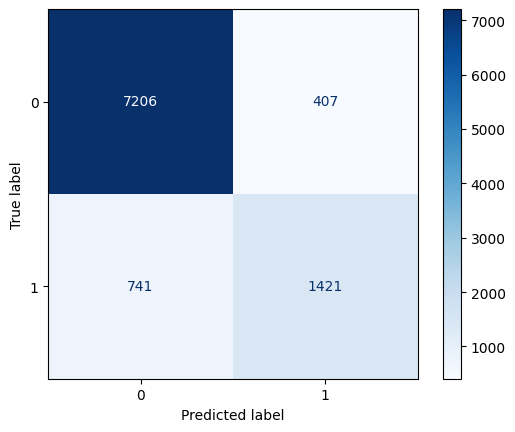

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Criando as previsões
y_pred = modelo.predict(x_test)

# Gerando a matriz
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

# Plotando o gráfico
disp.plot(cmap='Blues')

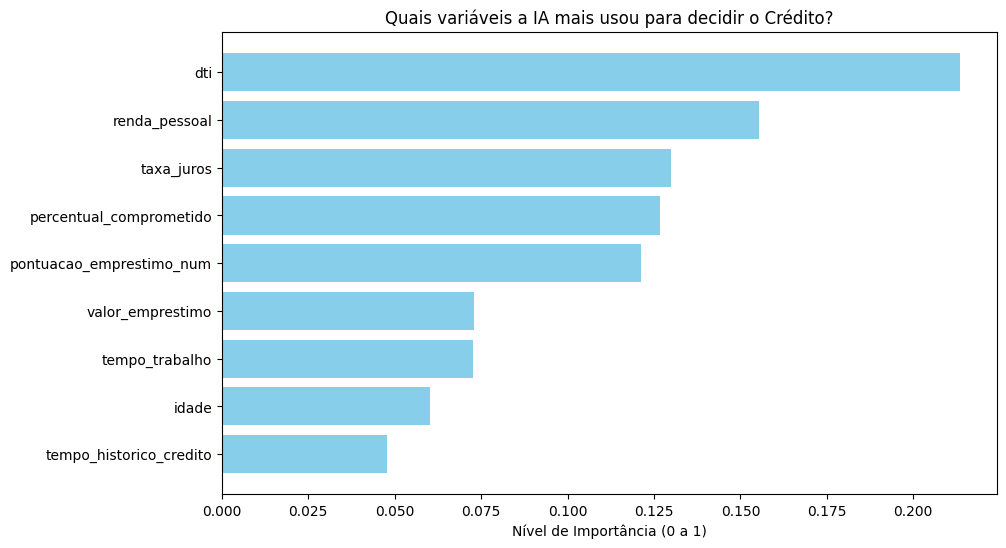

In [ ]:
# 1. Pegar as importâncias do Random Forest
importancias = modelo.feature_importances_
features = x.columns

# 2. Criar um DataFrame para facilitar a visualização
df_importancia = pd.DataFrame({'Variavel': features, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=True)

# 3. Plotar o gráfico
plt.figure(figsize=(10, 6))
plt.barh(df_importancia['Variavel'], df_importancia['Importancia'], color='skyblue')
plt.xlabel('Nível de Importância (0 a 1)')
plt.title('Quais variáveis a IA mais usou para decidir o Crédito?')
plt.show()

In [ ]:
dados_exemplos = [
    {
        'idade': 40, 'renda_pessoal': 90000, 'tempo_trabalho': 12,
        'valor_emprestimo': 4500, 'taxa_juros': 7.0, 'dti': 0.05,
        'pontuacao_emprestimo_num': 1, 'tipo_moradia_MORTGAGE': 1,
        'historico_inadimplencia_N': 1, 'objetivo_emprestimo_PERSONAL': 1
    },
    {
        'idade': 20, 'renda_pessoal': 15000, 'tempo_trabalho': 0.5,
        'valor_emprestimo': 11250, 'taxa_juros': 20.0, 'dti': 0.75,
        'pontuacao_emprestimo_num': 6, 'tipo_moradia_RENT': 1,
        'historico_inadimplencia_Y': 1, 'objetivo_emprestimo_MEDICAL': 1
    },
    {
        'idade': 28, 'renda_pessoal': 45000, 'tempo_trabalho': 4,
        'valor_emprestimo': 13500, 'taxa_juros': 13.0, 'dti': 0.30,
        'pontuacao_emprestimo_num': 3, 'tipo_moradia_RENT': 1,
        'historico_inadimplencia_N': 1, 'objetivo_emprestimo_DEBTCONSOLIDATION': 1
    }
]

# 2. Criar o DataFrame de simulação com as colunas EXATAS do seu modelo (X)
df_simulacao = pd.DataFrame(columns=x.columns)

# 3. Preencher os perfis (garantindo que o que não foi definido acima receba 0)
for i, perfil in enumerate(dados_exemplos):
    df_simulacao.loc[i] =
    for coluna, valor in perfil.items():
        if coluna in df_simulacao.columns:
            df_simulacao.at[i, coluna] = valor

# 4. Rodar a Predição

probabilidades = modelo.predict_proba(df_simulacao)

# 5. Exibir resultados
print("--- RESULTADOS DA SIMULAÇÃO DE CRÉDITO ---")
labels = ["CLIENTE PRIME", "CLIENTE CRÍTICO", "CLIENTE MODERADO"]
for i, label in enumerate(labels):
    risco = probabilidades[i][1]
    print(f"{label}: Probabilidade de Inadimplência = {risco:.2%}")

--- RESULTADOS DA SIMULAÇÃO DE CRÉDITO ---
CLIENTE PRIME: Probabilidade de Inadimplência = 5.00%
CLIENTE CRÍTICO: Probabilidade de Inadimplência = 83.00%
CLIENTE MODERADO: Probabilidade de Inadimplência = 52.00%


/tmp/ipykernel_5231/785478931.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.05' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_simulacao.at[i, coluna] = valor
/tmp/ipykernel_5231/785478931.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_simulacao.at[i, coluna] = valor


In [ ]:
df_simulacao.head()

,idade,renda_pessoal,tempo_trabalho,valor_emprestimo,taxa_juros,percentual_comprometido,tempo_historico_credito,dti,pontuacao_emprestimo_num
0,40,90000,12.0,4500,7,0,0,0.05,1
1,20,15000,0.5,11250,20,0,0,0.75,6
2,28,45000,4.0,13500,13,0,0,0.30,3
